In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# Load dataset
# Assume we have a DataFrame 'data' with columns 'Date', 'AAA_return', and 'MSCI_return'
data = pd.read_csv('Nov_return_data.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.fillna(0)
asset_no = data.shape[1] - 2 # not counting Date, MSCI
print (asset_no)
print (data)

22
         Date      Euro       GBP       JPY       CNY  MSCI  Natural_Gas  \
0  2023-10-03  0.449632  0.505427 -0.427236  0.000000 -1.38         3.84   
1  2023-10-04 -0.617988 -0.723863 -0.221239  0.000000  0.40         0.44   
2  2023-10-05 -0.085494 -0.115028 -0.228449  0.000000  0.20         6.89   
3  2023-10-06 -0.651189 -0.685435  0.397333  0.000000  1.02         5.43   
4  2023-10-09 -0.207195 -0.268555 -0.308559 -0.016447  0.47         1.14   
5  2023-10-10 -0.207195 -0.268555 -0.308559 -0.016447  1.02         0.18   
6  2023-10-11 -0.018832 -0.130039  0.370071  0.060317  0.40        -0.15   
7  2023-10-12  0.634891  0.736859  0.362003  0.036990 -0.53        -0.98   
8  2023-10-13  0.485622  0.617843 -0.060116  0.041085 -0.76        -3.23   
9  2023-10-16 -0.417220 -0.483686 -0.033418  0.076661  0.81        -3.92   
10 2023-10-17 -0.443689 -0.065542  0.093602  0.000000  0.11        -0.96   
11 2023-10-18  0.579187  0.460905  0.100194  0.076602 -1.27        -0.75   
12 2023-1

In [3]:
# Define the event and event window
event_date = pd.to_datetime('2023-11-21')  # Replace with actual event date
estimation_start = pd.to_datetime('2023-10-03')
estimation_end = pd.to_datetime('2023-11-14')
event_start = pd.to_datetime('2023-11-15')
event_end = pd.to_datetime('2023-11-29')

estimation_data = data[(data['Date'] >= estimation_start) & (data['Date'] <= estimation_end)]
print (estimation_data)
event_data = data[(data['Date'] >= event_start) & (data['Date'] <= event_end)]
print (event_data)

         Date      Euro       GBP       JPY       CNY  MSCI  Natural_Gas  \
0  2023-10-03  0.449632  0.505427 -0.427236  0.000000 -1.38         3.84   
1  2023-10-04 -0.617988 -0.723863 -0.221239  0.000000  0.40         0.44   
2  2023-10-05 -0.085494 -0.115028 -0.228449  0.000000  0.20         6.89   
3  2023-10-06 -0.651189 -0.685435  0.397333  0.000000  1.02         5.43   
4  2023-10-09 -0.207195 -0.268555 -0.308559 -0.016447  0.47         1.14   
5  2023-10-10 -0.207195 -0.268555 -0.308559 -0.016447  1.02         0.18   
6  2023-10-11 -0.018832 -0.130039  0.370071  0.060317  0.40        -0.15   
7  2023-10-12  0.634891  0.736859  0.362003  0.036990 -0.53        -0.98   
8  2023-10-13  0.485622  0.617843 -0.060116  0.041085 -0.76        -3.23   
9  2023-10-16 -0.417220 -0.483686 -0.033418  0.076661  0.81        -3.92   
10 2023-10-17 -0.443689 -0.065542  0.093602  0.000000  0.11        -0.96   
11 2023-10-18  0.579187  0.460905  0.100194  0.076602 -1.27        -0.75   
12 2023-10-1

In [4]:
# expected, abnormal returns for full period; cumulative abnormal return for event period

def calculate_returns(data, asset, event_date, estimation_start, estimation_end, event_start, event_end):

    # Prepare estimation data
    estimation_data = data[(data['Date'] >= estimation_start) & (data['Date'] <= estimation_end)]
    y = estimation_data[asset]
    X = sm.add_constant(estimation_data['MSCI'])

    # Fit the market model
    model = sm.OLS(y, X).fit()
    alpha, beta = model.params

    # Calculate expected returns and abnormal returns for both windows
    full_period = data[(data['Date'] >= estimation_start) & (data['Date'] <= event_end)].copy()
    full_period[f'{asset}_expected_return'] = alpha + beta * full_period['MSCI']
    full_period[f'{asset}_abnormal_return'] = full_period[asset] - full_period[f'{asset}_expected_return']

    # Calculate CAR for event window
    event_period = full_period[(full_period['Date'] >= event_start) & (full_period['Date'] <= event_end)]
    event_period[f'{asset}_CAR'] = event_period[f'{asset}_abnormal_return'].cumsum()

    return full_period, event_period, model

In [5]:
    # Function to add significance markers
    def add_markers(p_value):
        if p_value < 0.01:
            return '***'
        elif p_value < 0.05:
            return '**'
        elif p_value < 0.1:
            return '*'
        else:
            return ''


In [6]:
# t- and p-value calculations

def calculate_significance(data, asset, model, estimation_data):
    # Calculate the mean squared error
    mse = model.mse_resid

    # Calculate the variance-covariance matrix
    X = sm.add_constant(estimation_data['MSCI'])
    vcv = mse * np.linalg.inv(X.T.dot(X))

    for index, row in data.iterrows():
        X_event = np.array([1, row['MSCI']])
        se = np.sqrt(mse * (1 + X_event.dot(np.linalg.inv(X.T.dot(X))).dot(X_event)))

        # For Abnormal Returns
        ar = row[f'{asset}_abnormal_return']
        t_stat_ar = ar / se
        p_value_ar = 2 * (1 - stats.t.cdf(abs(t_stat_ar), df=len(estimation_data)-2))

        # For Cumulative Abnormal Returns
        car = row[f'{asset}_CAR']
        days = row['CAR_days']
        se_car = se * np.sqrt(days)
        t_stat_car = car / se_car
        p_value_car = 2 * (1 - stats.t.cdf(abs(t_stat_car), df=len(estimation_data)-2))

        data.at[index, f'{asset}_AR_t_stat'] = t_stat_ar
        data.at[index, f'{asset}_AR_p_value'] = p_value_ar
        data.at[index, f'{asset}_CAR_t_stat'] = t_stat_car
        data.at[index, f'{asset}_CAR_p_value'] = p_value_car


    return data

In [7]:
#   calculate_AGGR_significance

def calculate_AGGR_significance(event_period, asset_no, estimation_data):

    se_aggr = np.std(estimation_data['Aggregate_AR']) / np.sqrt(asset_no)

    event_period['Aggregate_AR_t'] = event_period['Aggregate_AR'] / se_aggr
    event_period['Aggregate_AR_p'] = 2 * (1 - stats.t.cdf(abs(event_period['Aggregate_AR_t']), df=len(estimation_data)-1))

    event_period['Aggregate_CAR_t'] = event_period['Aggregate_CAR'] / (se_aggr * np.sqrt(range(1, len(event_data)+1)))
    event_period['Aggregate_CAR_p'] = 2 * (1 - stats.t.cdf(abs(event_period['Aggregate_CAR_t']), df=len(estimation_data)-1))

    return event_period



In [8]:
# another way to prepare the table
import os
def prepare_ar_table(results, assets, event_start, event_end):
    # Define event period
    event_data = results[(results['Date'] >= event_start) & (results['Date'] <= event_end)]

    # Initialize an empty DataFrame to store the results
    table_df = pd.DataFrame(index=event_data.index)

    # Iterate over each asset
    for asset in assets:
        # Construct the column names for abnormal return and p-value
        abnormal_return_col = f'{asset}_abnormal_return'
        p_value_col = f'{asset}_AR_p_value'

        # Calculate significance notation
        significance = np.select(
            [
                event_data[p_value_col] < 0.01,
                event_data[p_value_col] < 0.05,
                event_data[p_value_col] < 0.1
            ],
            [
                '***',
                '**',
                '*'
            ],
            default=''
        )

        # Combine abnormal return, p-value, and significance into a single string
        table_df[asset] = event_data[abnormal_return_col].round(4).astype(str) + ' (' + event_data[p_value_col].round(4).astype(str) + ') ' + significance

    return table_df

# Example usage
# assets = ['AAPL', 'GOOG']
# prepared_table = prepare_data_table(df, assets)
# print(prepared_table)


In [9]:
# another way to prepare the table
import os
def prepare_car_table(results, assets, event_start, event_end):
    # Define event period
    event_data = results[(results['Date'] >= event_start) & (results['Date'] <= event_end)]

    # Initialize an empty DataFrame to store the results
    table_df = pd.DataFrame(index=event_data.index)

    # Iterate over each asset
    for asset in assets:
        # Construct the column names for abnormal return and p-value
        car_return_col = f'{asset}_CAR'
        p_value_col = f'{asset}_CAR_p_value'

        # Calculate significance notation
        significance = np.select(
            [
                event_data[p_value_col] < 0.01,
                event_data[p_value_col] < 0.05,
                event_data[p_value_col] < 0.1
            ],
            [
                '***',
                '**',
                '*'
            ],
            default=''
        )

        # Combine abnormal return, p-value, and significance into a single string
        table_df[asset] = event_data[car_return_col].round(4).astype(str) + ' (' + event_data[p_value_col].round(4).astype(str) + ') ' + significance

    return table_df


In [10]:
# another way to prepare the table
import os
def prepare_ARR_table(results, assets, event_start, event_end):
    # Define event period
    event_data = results[(results['Date'] >= event_start) & (results['Date'] <= event_end)]

    # Initialize an empty DataFrame to store the results
    table_df = pd.DataFrame(index=event_data.index)

    # Construct the column names for abnormal return and p-value
    abnormal_return_col = 'Aggregate_AR'
    p_value_col = 'Aggregate_AR_p'

    # Calculate significance notation
    significance = np.select(
        [
            event_data[p_value_col] < 0.01,
            event_data[p_value_col] < 0.05,
            event_data[p_value_col] < 0.1
        ],
        [
            '***',
            '**',
             '*'
        ],
        default=''
    )

    # Combine abnormal return, p-value, and significance into a single string
    table_df['Aggregate_AR'] = event_data[abnormal_return_col].round(4).astype(str) + ' (' + event_data[p_value_col].round(4).astype(str) + ') ' + significance

    # Construct the column names for abnormal return and p-value
    abnormal_return_col = 'Aggregate_CAR'
    p_value_col = 'Aggregate_CAR_p'

    # Calculate significance notation
    significance = np.select(
        [
            event_data[p_value_col] < 0.01,
            event_data[p_value_col] < 0.05,
            event_data[p_value_col] < 0.1
        ],
        [
            '***',
            '**',
             '*'
        ],
        default=''
    )

    # Combine abnormal return, p-value, and significance into a single string
    table_df['Aggregate_CAR'] = event_data[abnormal_return_col].round(4).astype(str) + ' (' + event_data[p_value_col].round(4).astype(str) + ') ' + significance


    return table_df


In [11]:
# main body 1: return (exp, abnormal, CAR, AG, AG_CAR) calculations

results = data.copy()
assets = [col for col in data.columns if col not in ['Date', 'MSCI']]

# calculate returns for all assets
for asset in assets:
    print(f"\nPerforming return calculations for {asset}")

    # Calculate returns
    full_period, event_period, model = calculate_returns(data, asset, event_date, estimation_start, estimation_end, event_start, event_end)

    # Add columns to results DataFrame
    results[f'{asset}_expected_return'] = full_period[f'{asset}_expected_return']
    results[f'{asset}_abnormal_return'] = full_period[f'{asset}_abnormal_return']
    results[f'{asset}_CAR'] = np.nan
    results.loc[event_period.index, f'{asset}_CAR'] = event_period[f'{asset}_CAR']

# calculate aggregate abnormal results (it's average over all assests)
for index, row in results.iterrows():
    agr_ar = 0
    for asset in assets:
        agr_ar += row[f'{asset}_abnormal_return']
    results.at[index,'Aggregate_AR'] = agr_ar/asset_no
print (results)

# calculate cumulative aggregate abnormal results for the event window
event_period = results[(results['Date'] >= event_start) & (results['Date'] <= event_end)]
event_period['Aggregate_CAR'] = event_period['Aggregate_AR'].cumsum()
#event_period[f'{asset}_CAR_days'] = range(1, len(event_period) + 1)

results['Aggregate_CAR'] = np.nan
results.loc[event_period.index, 'Aggregate_CAR'] = event_period['Aggregate_CAR']

# CAR_days:
event_period['CAR_days'] = range(1, len(event_period) + 1)
results['CAR_days'] = np.nan
results.loc[event_period.index, 'CAR_days'] = event_period['CAR_days']


print('Finally, results:')
print(results)


Performing return calculations for Euro

Performing return calculations for GBP

Performing return calculations for JPY

Performing return calculations for CNY

Performing return calculations for Natural_Gas

Performing return calculations for Brent_Oil

Performing return calculations for Silver

Performing return calculations for Gold

Performing return calculations for GSCI_Precious_Metal

Performing return calculations for CAC40

Performing return calculations for DAX

Performing return calculations for Dow_Jones

Performing return calculations for FTSE_100

Performing return calculations for FTSE_MIB

Performing return calculations for Nikkei_225

Performing return calculations for SHCOMP

Performing return calculations for BTC

Performing return calculations for ETH

Performing return calculations for BNB

Performing return calculations for SOL

Performing return calculations for XRP

Performing return calculations for DOGE
         Date      Euro       GBP       JPY       CNY  M

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)
C:\Users\A00017~1\AppData\Local\Temp/ipykernel_3960/662761975.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_period[f'{asset}_CAR'] = event_period[f'{asset}_abnormal_return'].cumsum()
C:\Users\A00017~1\AppData\Local\Temp/ipykernel_3960/623206860.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#return

In [12]:
# main body 2: significance calculations
event_period = results[(results['Date'] >= event_start) & (results['Date'] <= event_end)]
estimation_period = results[(results['Date'] >= estimation_start) & (results['Date'] <= estimation_end)]
#print (estimation_period)
#print (event_period)

for asset in assets:
    print(f"\nPerforming significance calculations for {asset}")

    # Calculate significance for event window
    event_results = calculate_significance(event_period, asset, model, estimation_period)

    # Add significance results to main results DataFrame
    for col in [f'{asset}_AR_t_stat', f'{asset}_AR_p_value', f'{asset}_CAR_t_stat', f'{asset}_CAR_p_value']:
        results[col] = np.nan
        results.loc[event_results.index, col] = event_results[col]

print('Significances for assets:')
print(results)

event_AGGR_results = calculate_AGGR_significance(event_period, asset_no, estimation_period)
for col in ['Aggregate_AR_t', 'Aggregate_AR_p', 'Aggregate_CAR_t', 'Aggregate_CAR_p']:
    results[col] = np.nan
    results.loc[event_AGGR_results.index, col] = event_AGGR_results[col]

print('Significances for Aggregates:')
print(results)


C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)
C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\indexing.py:1684: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = infer_fill_value(value)
C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._


Performing significance calculations for Euro

Performing significance calculations for GBP

Performing significance calculations for JPY

Performing significance calculations for CNY

Performing significance calculations for Natural_Gas

Performing significance calculations for Brent_Oil

Performing significance calculations for Silver

Performing significance calculations for Gold

Performing significance calculations for GSCI_Precious_Metal

Performing significance calculations for CAC40

Performing significance calculations for DAX

Performing significance calculations for Dow_Jones

Performing significance calculations for FTSE_100

Performing significance calculations for FTSE_MIB

Performing significance calculations for Nikkei_225

Performing significance calculations for SHCOMP

Performing significance calculations for BTC

Performing significance calculations for ETH

Performing significance calculations for BNB

Performing significance calculations for SOL

Performing signi

C:\Users\A00017~1\AppData\Local\Temp/ipykernel_3960/3677676422.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_period['Aggregate_AR_t'] = event_period['Aggregate_AR'] / se_aggr
C:\Users\A00017~1\AppData\Local\Temp/ipykernel_3960/3677676422.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_period['Aggregate_AR_p'] = 2 * (1 - stats.t.cdf(abs(event_period['Aggregate_AR_t']), df=len(estimation_data)-1))
C:\Users\A00017~1\AppData\Local\Temp/ipykernel_3960/3677676422.py:10: SettingWithCopyWarnin

In [13]:
# Main body 3: print tables

print('Abnormal return table:')
ar_table = prepare_ar_table(results, assets, event_start, event_end)
print(ar_table)
print('Cumulative abnormal return table:')
car_table = prepare_car_table(results, assets, event_start, event_end)
print(car_table)
print('Aggregate abnormal return table:')
ARR_table = prepare_ARR_table(results, assets, event_start, event_end)
print(ARR_table)



Abnormal return table:
                 Euro                GBP                JPY  \
31   0.2716 (0.9167)    0.6162 (0.8126)    0.2148 (0.9341)    
32   0.0583 (0.9821)    0.0775 (0.9762)   -0.3608 (0.8895)    
33  -0.0561 (0.9828)    0.1455 (0.9553)   -0.5078 (0.8451)    
34  -0.3177 (0.9031)   -0.2997 (0.9085)    -1.0134 (0.698)    
35   0.2077 (0.9363)   -0.3053 (0.9065)   -0.3091 (0.9053)    
36   0.5956 (0.8185)      0.681 (0.793)    1.1897 (0.6471)    
37  -0.4691 (0.8566)   -0.9637 (0.7106)   -0.0905 (0.9722)    
38  -0.4422 (0.8647)   -0.9323 (0.7196)   -0.0827 (0.9746)    
39  -0.0447 (0.9863)   -0.1489 (0.9544)   -0.5143 (0.8434)    
40  -0.5221 (0.8405)    -0.687 (0.7913)   -1.0158 (0.6958)    
41   0.4267 (0.8694)    0.2415 (0.9258)    -0.045 (0.9862)    

                  CNY           Natural_Gas           Brent_Oil  \
31   -0.0554 (0.983)     7.896 (0.0047) ***    -1.1482 (0.659)    
32     -0.065 (0.98)       -4.015 (0.1297)   -4.4642 (0.0935) *   
33  -0.3752 (0.8852

In [14]:
# Write results to CSV

output_file = 'Nov_event_study_results.csv'
results.to_csv(output_file, index=False)
print(f"\nResults written to {output_file}")

#    output_file = f'{asset}_event_study_results.csv'
#    results.to_csv(output_file, index=False)
#    output_file = f'{asset}_event_period.csv'
#    event_period.to_csv(output_file, index=False)


Results written to Nov_event_study_results.csv


In [15]:
# plot abnormal and cumulative abnormal returns for event window

def plot_all_assets(results, assets, event_date, event_start, event_end):
    event_data = results[(results['Date'] >= event_start) & (results['Date'] <= event_end)]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16), sharex=True)

    # Plot Abnormal Returns
    for asset in assets:
        ax1.plot(event_data['Date'], event_data[f'{asset}_abnormal_return'], label=f'{asset} AR')

    ax1.axvline(x=event_date, color='r', linestyle='--', label='Event Date')
    ax1.set_ylabel('Abnormal Returns')
    ax1.set_title('Abnormal Returns for All Assets')
    ax1.legend(loc='best')
    ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

    # Plot Cumulative Abnormal Returns
    for asset in assets:
        ax2.plot(event_data['Date'], event_data[f'{asset}_CAR'], label=f'{asset} CAR')

    ax2.axvline(x=event_date, color='r', linestyle='--', label='Event Date')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Cumulative Abnormal Returns')
    ax2.set_title('Cumulative Abnormal Returns for All Assets')
    ax2.legend(loc='best')
    ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

    # Format x-axis
    plt.gcf().autofmt_xdate()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    # Adjust y-axis limits to be the same for both plots
    y_min = min(event_data[[f'{asset}_abnormal_return' for asset in assets]].min().min(),
                event_data[[f'{asset}_CAR' for asset in assets]].min().min())
    y_max = max(event_data[[f'{asset}_abnormal_return' for asset in assets]].max().max(),
                event_data[[f'{asset}_CAR' for asset in assets]].max().max())
    ax1.set_ylim(y_min * 1.1, y_max * 1.1)
    ax2.set_ylim(y_min * 1.1, y_max * 1.1)

    plt.tight_layout()
    plt.show()

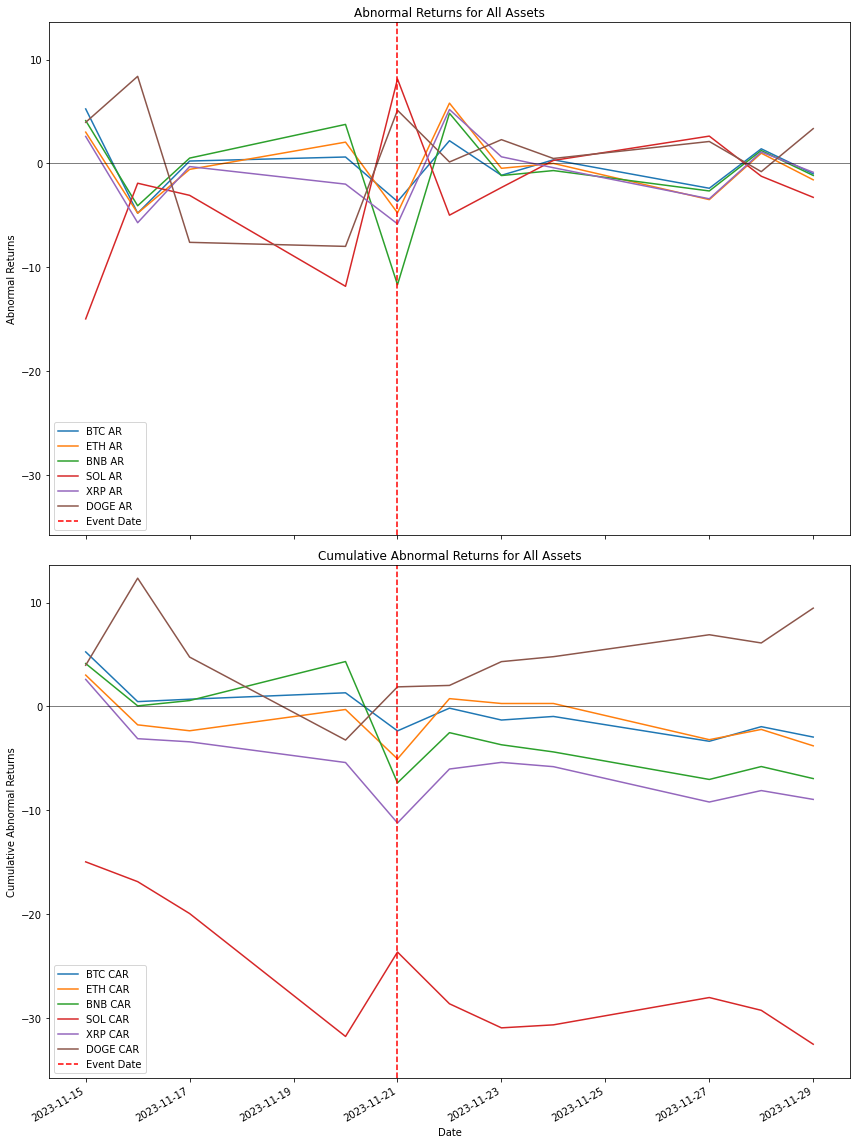

In [16]:
# plots
assets = [col for col in data.columns if col not in ['Date', 'MSCI']]
cryptos = [col for col in assets if col in ['BTC', 'ETH', 'BNB', 'SOL', 'XRP', 'DOGE']]
plot_all_assets(results, cryptos, event_date, event_start, event_end)

In [17]:
# boxplots for returns, periods

def plot_boxplots(results, assets, event_date, estimation_start, estimation_end, event_start, event_end):

    estimation_data = results[(results['Date'] >= estimation_start) & (results['Date'] <= estimation_end)]
    event_data = results[(results['Date'] >= event_start) & (results['Date'] <= event_end)]

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 20))

    # Actual Returns - Estimation Window
    estimation_actual = estimation_data[assets].melt()
    sns.boxplot(x='variable', y='value', data=estimation_actual, ax=ax1)
    ax1.set_title('Actual Returns - Estimation Window')
    ax1.set_xlabel('Assets')
    ax1.set_ylabel('Returns')
    ax1.tick_params(axis='x', rotation=45)

    # Actual Returns - Event Window
    event_actual = event_data[assets].melt()
    sns.boxplot(x='variable', y='value', data=event_actual, ax=ax2)
    ax2.set_title('Actual Returns - Event Window')
    ax2.set_xlabel('Assets')
    ax2.set_ylabel('Returns')
    ax2.tick_params(axis='x', rotation=45)

    # Abnormal Returns - Estimation Window
    estimation_abnormal = estimation_data[[f'{asset}_abnormal_return' for asset in assets]].melt()
    sns.boxplot(x='variable', y='value', data=estimation_abnormal, ax=ax3)
    ax3.set_title('Abnormal Returns - Estimation Window')
    ax3.set_xlabel('Assets')
    ax3.set_ylabel('Abnormal Returns')
    ax3.tick_params(axis='x', rotation=45)

    # Abnormal Returns - Event Window
    event_abnormal = event_data[[f'{asset}_abnormal_return' for asset in assets]].melt()
    sns.boxplot(x='variable', y='value', data=event_abnormal, ax=ax4)
    ax4.set_title('Abnormal Returns - Event Window')
    ax4.set_xlabel('Assets')
    ax4.set_ylabel('Abnormal Returns')
    ax4.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

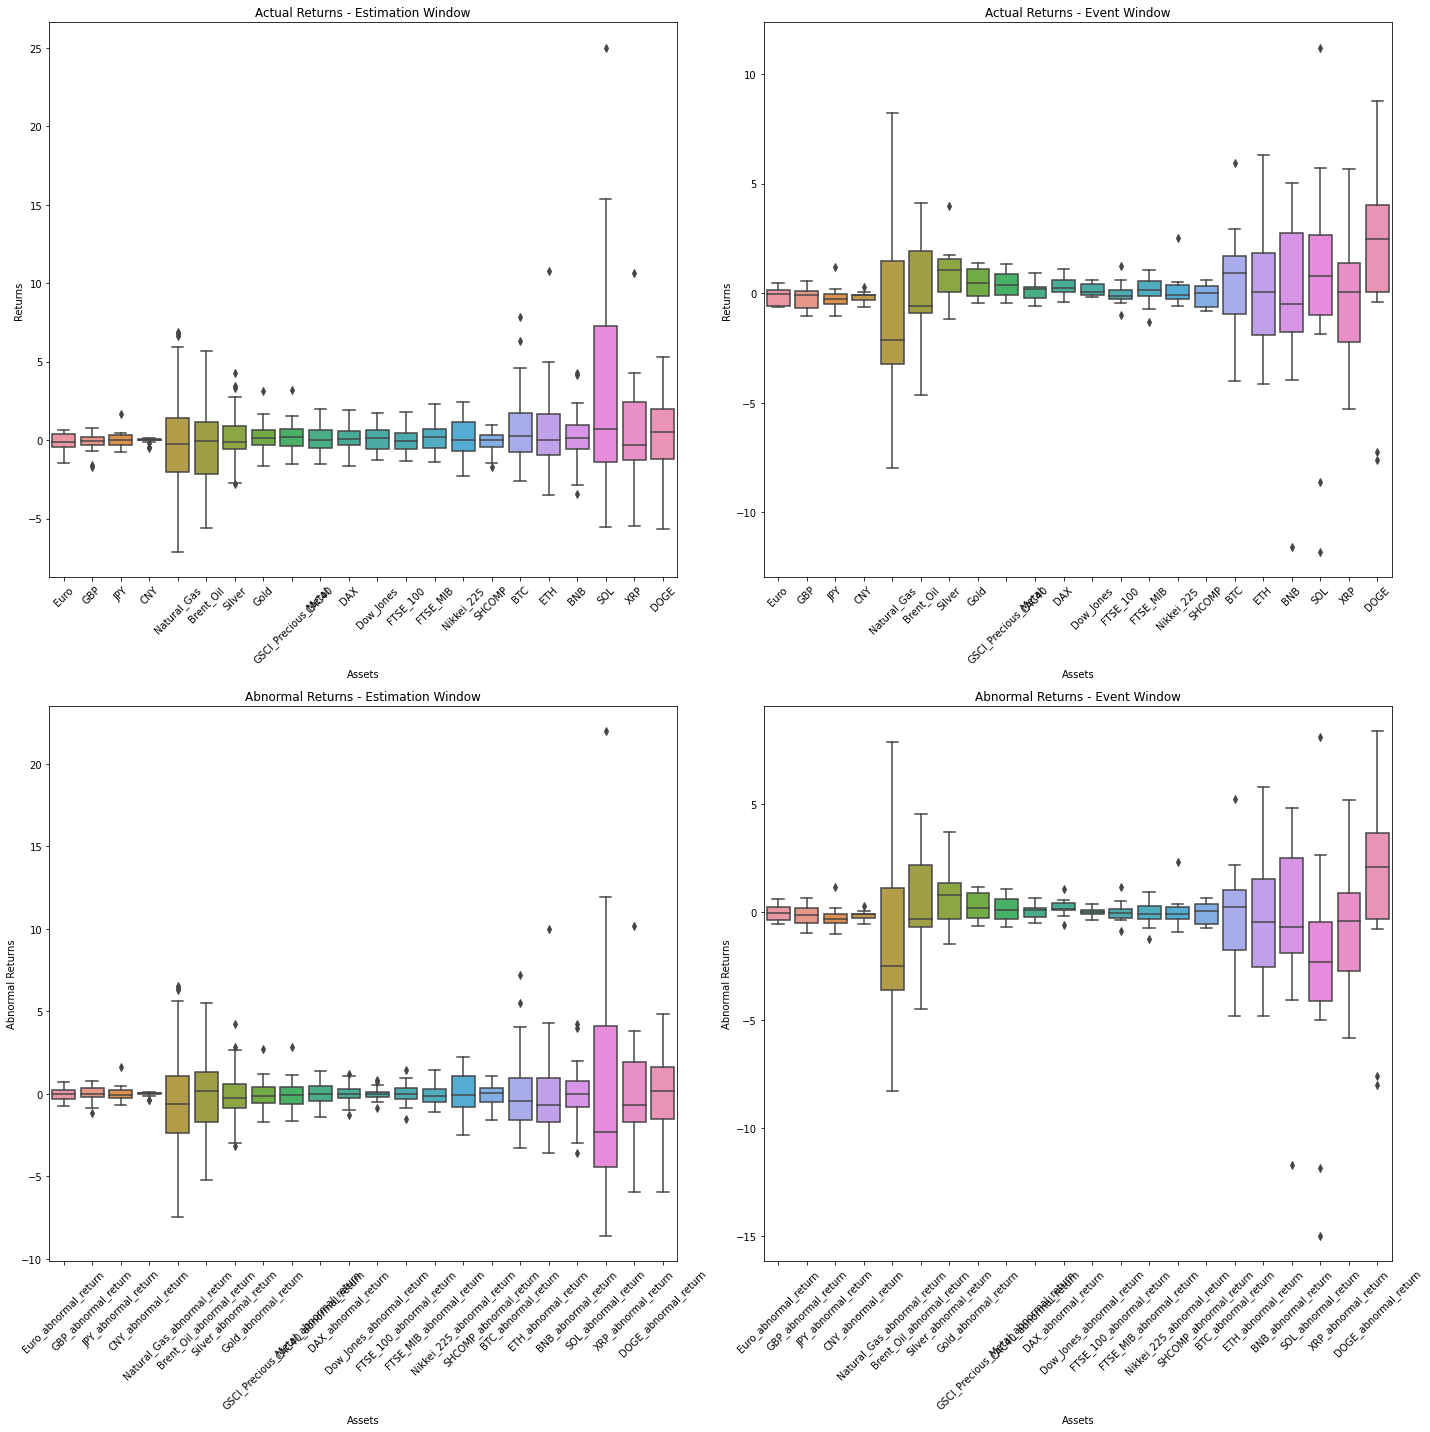

In [18]:
plot_boxplots(results, assets, event_date, estimation_start, estimation_end, event_start, event_end)

In [19]:
# correlation maps

def plot_correlation_heatmaps(results, assets, event_date, estimation_start, estimation_end, event_start, event_end):

    estimation_data = results[(results['Date'] >= estimation_start) & (results['Date'] <= estimation_end)]
    event_data = results[(results['Date'] >= event_start) & (results['Date'] <= event_end)]

    def correlation_with_pvalue(x, y):
        r, p = stats.pearsonr(x, y)
        return r, p

    def plot_heatmap(data, title):
        corr_matrix = data[assets].corr()
        p_matrix = data[assets].corr(method=lambda x, y: correlation_with_pvalue(x, y)[1])

        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

        # Custom colormap
        cmap = LinearSegmentedColormap.from_list("custom", ["#4575b4", "#ffffff", "#d73027"])

        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
                    annot=True, fmt='.2f', square=True, linewidths=.5, cbar_kws={"shrink": .5})

        # Add p-values to the heatmap
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                plt.text(j+0.5, i+0.5, f'({p_matrix.iloc[i, j]:.3f})',
                         ha='center', va='center', color='black')

        plt.title(title)
        plt.tight_layout()
        plt.show()

    plot_heatmap(estimation_data, 'Correlation Heatmap - Estimation Window')
    plot_heatmap(event_data, 'Correlation Heatmap - Event Window')

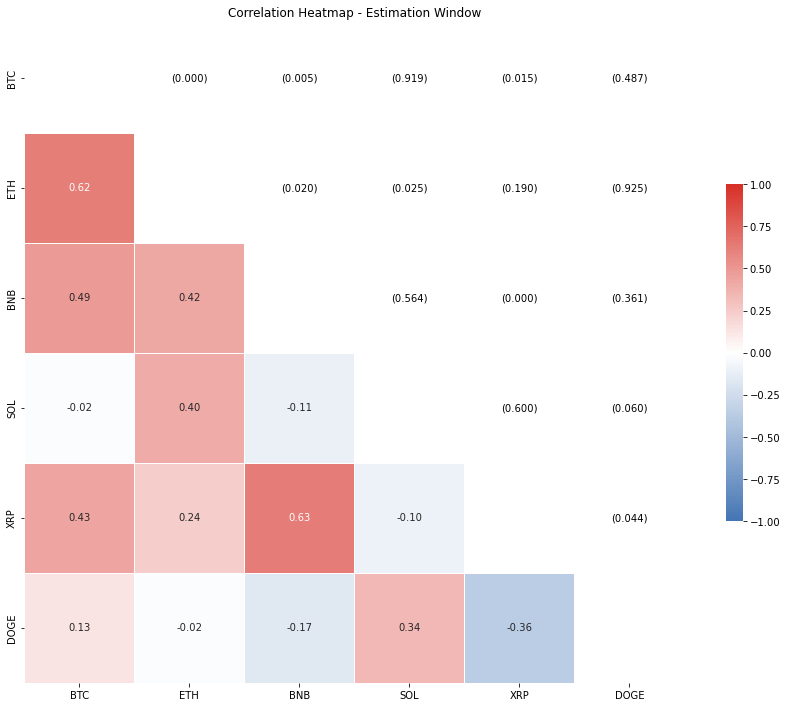

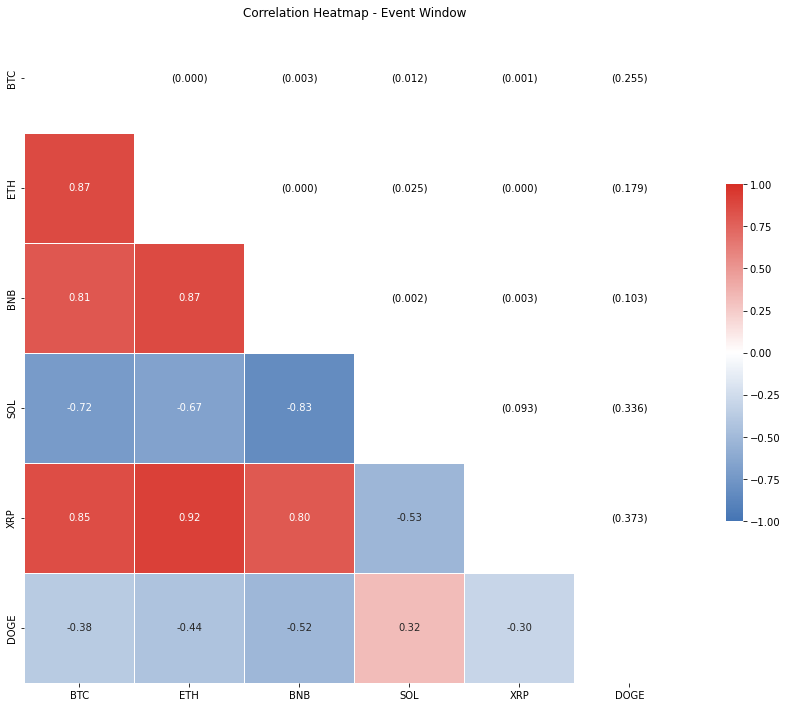

In [20]:
plot_correlation_heatmaps(results, cryptos, event_date, estimation_start, estimation_end, event_start, event_end)